# SFUMATO vs FICTURE

This notebook compares SFUMATO clusters with FICTURE clusters.

It produces two heatmaps:
1. all SFUMATO assignments, without probability filtering;
2. high-confidence SFUMATO assignments, using `p1 >= P1_THRESHOLD`.

Matching can be done by rounded/integer coordinates or by an explicit shared ID.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, to_rgb

try:
    from scipy.cluster import hierarchy
except Exception:
    hierarchy = None

sns.set_theme(style="white", context="paper")
pd.set_option("display.max_columns", 80)


c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\_utils\__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
# -------------------------
# Parameters
# -------------------------
SFUMATO_H5AD = r"full\newcolors\mousexeniumcell_BGM68to45_BIN7_F5_SVD10_FULL.h5ad"
FICTURE_TABLE = r"C:\Users\alegi784\Desktop\PhD\BayesianClustering\dp-gmm\ficture\pixel_anchor_projection_n45.csv"

OUTPUT_DIR = "sfumato_ficture_comparison"
P1_THRESHOLD = 0.8
NORMALIZATION = "row"  # "row", "column", or "none"

# Matching options
MATCH_METHOD = "coordinate"  # "coordinate" or "id"
COORDINATE_METHOD = "astype_int"  # "astype_int", "round", or "floor"
SFUMATO_COORD_SCALE = 1.0
FICTURE_COORD_SCALE = 1.0

# SFUMATO columns in adata.obs
SFUMATO_X_COL = "x"
SFUMATO_Y_COL = "y"
SFUMATO_ID_COL = ""  # used only if MATCH_METHOD == "id"
SFUMATO_CLUSTER_COL = "cluster"
SFUMATO_COLOR_COL = "color_hard"
SFUMATO_P1_COL = "p1"
SFUMATO_COMPL_P1_COL = "compl_p1"

# FICTURE columns
FICTURE_X_COL = "X"
FICTURE_Y_COL = "Y"
FICTURE_ID_COL = ""  # used only if MATCH_METHOD == "id"
FICTURE_CLUSTER_COL = "cluster"


In [3]:
def read_table(path, **kwargs):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        return pd.read_parquet(path, **kwargs)
    if suffix in {".csv", ".txt"}:
        return pd.read_csv(path, **kwargs)
    if suffix in {".tsv", ".tab"}:
        return pd.read_csv(path, sep="\t", **kwargs)
    raise ValueError(f"Unsupported table format: {path}")


def decode_if_bytes(series):
    return series.map(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)


def add_confidence(obs, p1_col="p1", compl_p1_col="compl_p1"):
    obs = obs.copy()
    if p1_col in obs.columns:
        obs["p1"] = pd.to_numeric(obs[p1_col], errors="coerce")
    elif compl_p1_col in obs.columns:
        obs["p1"] = 1 - pd.to_numeric(obs[compl_p1_col], errors="coerce")
    else:
        warnings.warn(
            f"Neither {p1_col!r} nor {compl_p1_col!r} found. "
            "The high-confidence subset will be unavailable."
        )
        obs["p1"] = np.nan
    return obs


def add_integer_coordinates(df, x_col, y_col, x_out="x_int", y_out="y_int", scale=1.0, method="astype_int"):
    df = df.copy()
    x = pd.to_numeric(df[x_col], errors="coerce") / scale
    y = pd.to_numeric(df[y_col], errors="coerce") / scale
    if method == "round":
        df[x_out] = np.rint(x).astype("Int64")
        df[y_out] = np.rint(y).astype("Int64")
    elif method == "floor":
        df[x_out] = np.floor(x).astype("Int64")
        df[y_out] = np.floor(y).astype("Int64")
    elif method == "astype_int":
        df[x_out] = np.trunc(x).astype("Int64")
        df[y_out] = np.trunc(y).astype("Int64")
    else:
        raise ValueError("method must be one of: 'astype_int', 'round', 'floor'")
    return df


def clean_cluster_labels(series, drop_values=("-1", "nan", "None")):
    labels = series.astype("string")
    labels = labels.where(~labels.isna(), other=pd.NA)
    labels = labels.str.replace(r"\.0$", "", regex=True)
    return labels.where(~labels.isin(drop_values), other=pd.NA)


def load_json_mapping(path):
    if path is None or str(path).strip() == "":
        return None
    with open(path, "r") as f:
        data = json.load(f)
    return {str(k): float(v) for k, v in data.items()}


def grayscale_map(values, low=0.92, high=0.20):
    values = pd.Series(values, dtype="float64")
    finite = values.replace([np.inf, -np.inf], np.nan).dropna()
    if finite.empty:
        scaled = pd.Series(0.5, index=values.index)
    elif finite.max() == finite.min():
        scaled = pd.Series(0.5, index=values.index)
    else:
        scaled = (values - finite.min()) / (finite.max() - finite.min())
    scaled = scaled.fillna(0.0).clip(0, 1)
    gray = low + (high - low) * scaled
    return gray.map(lambda g: to_hex((g, g, g)))


def safe_color_map(df, label_col, color_col):
    if color_col is None or color_col not in df.columns:
        return {}
    tmp = df[[label_col, color_col]].dropna().copy()
    tmp[label_col] = clean_cluster_labels(tmp[label_col])
    tmp = tmp.dropna(subset=[label_col])
    return tmp.drop_duplicates(label_col).set_index(label_col)[color_col].astype(str).to_dict()


def build_matrix(df, row_col, col_col, normalization="row"):
    clean = df[[row_col, col_col]].dropna().copy()
    clean[row_col] = clean_cluster_labels(clean[row_col])
    clean[col_col] = clean_cluster_labels(clean[col_col])
    clean = clean.dropna(subset=[row_col, col_col])
    counts = clean.pivot_table(index=row_col, columns=col_col, aggfunc="size", fill_value=0)
    if counts.empty:
        raise ValueError("No overlapping assignments after filtering. Check input paths, columns, or coordinate matching.")
    counts = counts.sort_index(axis=0).sort_index(axis=1)
    if normalization == "row":
        denom = counts.sum(axis=1).replace(0, np.nan)
        matrix = counts.div(denom, axis=0).fillna(0)
    elif normalization == "column":
        denom = counts.sum(axis=0).replace(0, np.nan)
        matrix = counts.div(denom, axis=1).fillna(0)
    elif normalization in {"none", None}:
        matrix = counts
    else:
        raise ValueError("normalization must be 'row', 'column', or 'none'")
    return counts, matrix


def order_matrix(matrix, cluster_rows=True, order_columns_by_dominant_row=True):
    ordered = matrix.copy()
    if cluster_rows and ordered.shape[0] > 1 and hierarchy is not None:
        linkage_matrix = hierarchy.linkage(ordered.values, method="average", metric="euclidean")
        ordered = ordered.iloc[hierarchy.leaves_list(linkage_matrix)]
    if order_columns_by_dominant_row and ordered.shape[1] > 1:
        values = ordered.to_numpy()
        dominant = np.argmax(values, axis=0)
        weak = values.max(axis=0) <= 0
        dominant = np.where(weak, 10_000, dominant)
        ordered = ordered.iloc[:, np.argsort(dominant)]
    return ordered


def plot_heatmap(
    matrix,
    title,
    row_color_map=None,
    row_numeric_annotation=None,
    row_numeric_label="SFUMATO transcript fraction",
    col_color_map=None,
    col_numeric_annotation=None,
    col_numeric_label="Reference size",
    row_label="SFUMATO cluster",
    col_label="Reference cluster",
    cmap="inferno",
    output_path=None,
):
    matrix = order_matrix(matrix)
    row_colors = None
    row_ann = {}
    if row_color_map:
        row_ann["SFUMATO color"] = [row_color_map.get(str(idx), "#bdbdbd") for idx in matrix.index]
    if row_numeric_annotation is not None:
        row_values = pd.Series({str(k): v for k, v in row_numeric_annotation.items()})
        row_ann[row_numeric_label] = grayscale_map([row_values.get(str(idx), np.nan) for idx in matrix.index]).tolist()
    if row_ann:
        row_colors = pd.DataFrame(row_ann, index=matrix.index)

    col_colors = None
    col_ann = {}
    if col_color_map:
        col_ann["Reference color"] = [col_color_map.get(str(idx), "#bdbdbd") for idx in matrix.columns]
    if col_numeric_annotation is not None:
        col_values = pd.Series({str(k): v for k, v in col_numeric_annotation.items()})
        col_ann[col_numeric_label] = grayscale_map([col_values.get(str(idx), np.nan) for idx in matrix.columns]).tolist()
    if col_ann:
        col_colors = pd.DataFrame(col_ann, index=matrix.columns)

    fig_height = max(6, matrix.shape[0] * 0.35 + 2)
    fig_width = max(7, matrix.shape[1] * 0.35 + 2)
    g = sns.clustermap(
        matrix,
        row_cluster=False,
        col_cluster=False,
        cmap=cmap,
        row_colors=row_colors,
        col_colors=col_colors,
        cbar_pos=(0.02, 0.80, 0.03, 0.12),
        figsize=(fig_width, fig_height),
        yticklabels=True,
        xticklabels=True,
    )
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=8)
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=8)
    g.ax_heatmap.set_xlabel(col_label, fontsize=11)
    g.ax_heatmap.set_ylabel(row_label, fontsize=11)
    g.fig.suptitle(title, fontsize=13, y=1.02)
    if output_path:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        g.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_path}")
    plt.show()
    return g


In [4]:
adata = sc.read_h5ad(SFUMATO_H5AD)
ficture = read_table(FICTURE_TABLE)

print("SFUMATO obs columns:", adata.obs.columns.tolist())
print("FICTURE columns:", ficture.columns.tolist())
display(ficture.head(3))


SFUMATO obs columns: ['x', 'y', 'target_name', 'bin_id', 'cluster', 'color_hard', 'color_mixed', 'compl_p1', 'cluster_p2r', 'color_p2r']
FICTURE columns: ['X', 'Y', 'K1_anchor', 'cluster']


,X,Y,K1_anchor,cluster
0,10360.000000,4146.823529,19,19
1,10383.529412,4155.764706,19,19
2,10443.294118,4155.764706,19,19


In [5]:
obs = add_confidence(adata.obs, p1_col=SFUMATO_P1_COL, compl_p1_col=SFUMATO_COMPL_P1_COL)
obs_cols = [SFUMATO_CLUSTER_COL, "p1"]
if SFUMATO_COLOR_COL in obs.columns:
    obs_cols.append(SFUMATO_COLOR_COL)

if MATCH_METHOD == "coordinate":
    obs_cols += [SFUMATO_X_COL, SFUMATO_Y_COL]
elif MATCH_METHOD == "id":
    if not SFUMATO_ID_COL or not FICTURE_ID_COL:
        raise ValueError("Set SFUMATO_ID_COL and FICTURE_ID_COL when MATCH_METHOD == 'id'.")
    obs_cols.append(SFUMATO_ID_COL)
else:
    raise ValueError("MATCH_METHOD must be 'coordinate' or 'id'.")

missing_obs = [c for c in obs_cols if c not in obs.columns]
if missing_obs:
    raise KeyError(f"Missing SFUMATO columns in adata.obs: {missing_obs}")

sfumato = obs[obs_cols].copy()
sfumato = sfumato.rename(
    columns={
        SFUMATO_CLUSTER_COL: "sfumato_cluster",
        SFUMATO_COLOR_COL: "sfumato_color",
        SFUMATO_X_COL: "sfumato_x",
        SFUMATO_Y_COL: "sfumato_y",
        SFUMATO_ID_COL: "match_id",
    }
)
sfumato["sfumato_cluster"] = clean_cluster_labels(sfumato["sfumato_cluster"])

ficture_cols = [FICTURE_CLUSTER_COL]
if MATCH_METHOD == "coordinate":
    ficture_cols += [FICTURE_X_COL, FICTURE_Y_COL]
else:
    ficture_cols.append(FICTURE_ID_COL)

missing_ficture = [c for c in ficture_cols if c not in ficture.columns]
if missing_ficture:
    raise KeyError(f"Missing FICTURE columns: {missing_ficture}")

ficture2 = ficture[ficture_cols].copy()
ficture2 = ficture2.rename(
    columns={
        FICTURE_CLUSTER_COL: "ficture_cluster",
        FICTURE_X_COL: "ficture_x",
        FICTURE_Y_COL: "ficture_y",
        FICTURE_ID_COL: "match_id",
    }
)
ficture2["ficture_cluster"] = clean_cluster_labels(ficture2["ficture_cluster"])

if MATCH_METHOD == "coordinate":
    sfumato = add_integer_coordinates(
        sfumato, "sfumato_x", "sfumato_y",
        scale=SFUMATO_COORD_SCALE, method=COORDINATE_METHOD
    )
    ficture2 = add_integer_coordinates(
        ficture2, "ficture_x", "ficture_y",
        scale=FICTURE_COORD_SCALE, method=COORDINATE_METHOD
    )
    ficture2 = ficture2.drop_duplicates(subset=["x_int", "y_int", "ficture_cluster"])
    merged = sfumato.merge(ficture2, on=["x_int", "y_int"], how="inner")
else:
    merged = sfumato.merge(ficture2, on="match_id", how="inner")

print(f"Matched rows: {len(merged):,}")
display(merged.head())


Matched rows: 26,302,566


,sfumato_cluster,p1,sfumato_color,sfumato_x,sfumato_y,x_int,y_int,ficture_cluster,ficture_x,ficture_y
0,15,0.978788,#6fe100,25503,4018,25503,4018,3,25503.058824,4018.352941
1,15,0.998898,#6fe100,25504,3984,25504,3984,3,25504.470588,3984.470588
2,15,0.998241,#6fe100,25524,3990,25524,3990,3,25524.235294,3990.117647
3,32,0.507923,#ff6804,25545,4221,25545,4221,1,25545.411765,4221.647059
4,13,0.887020,#52d500,25553,4059,25553,4059,3,25553.411765,4059.294118


In [6]:
sfumato_color_map = safe_color_map(merged, "sfumato_cluster", "sfumato_color")

def run_ficture_comparison(df, label):
    counts, matrix = build_matrix(df, "sfumato_cluster", "ficture_cluster", normalization=NORMALIZATION)
    print(f"{label}: matrix shape = {matrix.shape}; total overlap count = {counts.to_numpy().sum():,}")
    display(counts.head())
    output_path = Path(OUTPUT_DIR) / f"sfumato_vs_ficture_{label}.pdf"
    return plot_heatmap(
        matrix,
        title=f"SFUMATO vs FICTURE ({label}; {NORMALIZATION}-normalized)",
        row_color_map=sfumato_color_map,
        row_label="SFUMATO cluster",
        col_label="FICTURE cluster",
        output_path=output_path,
    )


all: matrix shape = (45, 45); total overlap count = 26,230,909


ficture_cluster,0,1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,5,6,7,8,9
sfumato_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,221,31503,235,195,2207,120,1450,122,371,647,283,181,1646,175,899,167,229,7022,715,171,740,9362,518,233,4130,15972,1015,236,555,1776,66,1083,391,130,618,626,315,1841,1557,277,830,533,47551,455,2269
1,4,1140,29,56,1628,54,275,24,246,132,79,139,3009,105,734,46,114,3844,25,23,468,6383,127,35,2699,23668,2000,114,628,343,90,165,194,116,305,793,253,368,463,148,144,248,111414,206,496
10,204,27111,26083,654,554,816,7068,3101,3439,23406,23263,465,29315,7238,13869,1224,2096,27532,6321,1078,5777,5061,947,15773,1592,156953,5474,1996,3686,5750,420,7752,2719,618,2132,1695,4089,11989,5173,6155,1780,51927,7893,1682,3711
11,972,3201,109922,650,323,2495,42679,301699,3878,1563,392370,434,8393,22966,264249,13081,1891,14643,6071,3388,3569,2260,1585,5276,102,39198,14613,4205,21576,3858,589,2547,358,636,2462,551,2659,7889,965,2370,4499,948383,6819,765,2248
12,3630,499,570619,631,224,154,41146,180290,2905,4325,33561,104,2312,3941,1906,8844,2992,4655,7779,2430,16788,279,3851,8784,26,1075,2955,704,1944,58,252,10290,173,128,564,295,2191,3303,206,3196,10848,46089,6102,288,141


Saved: sfumato_ficture_comparison\sfumato_vs_ficture_all.pdf


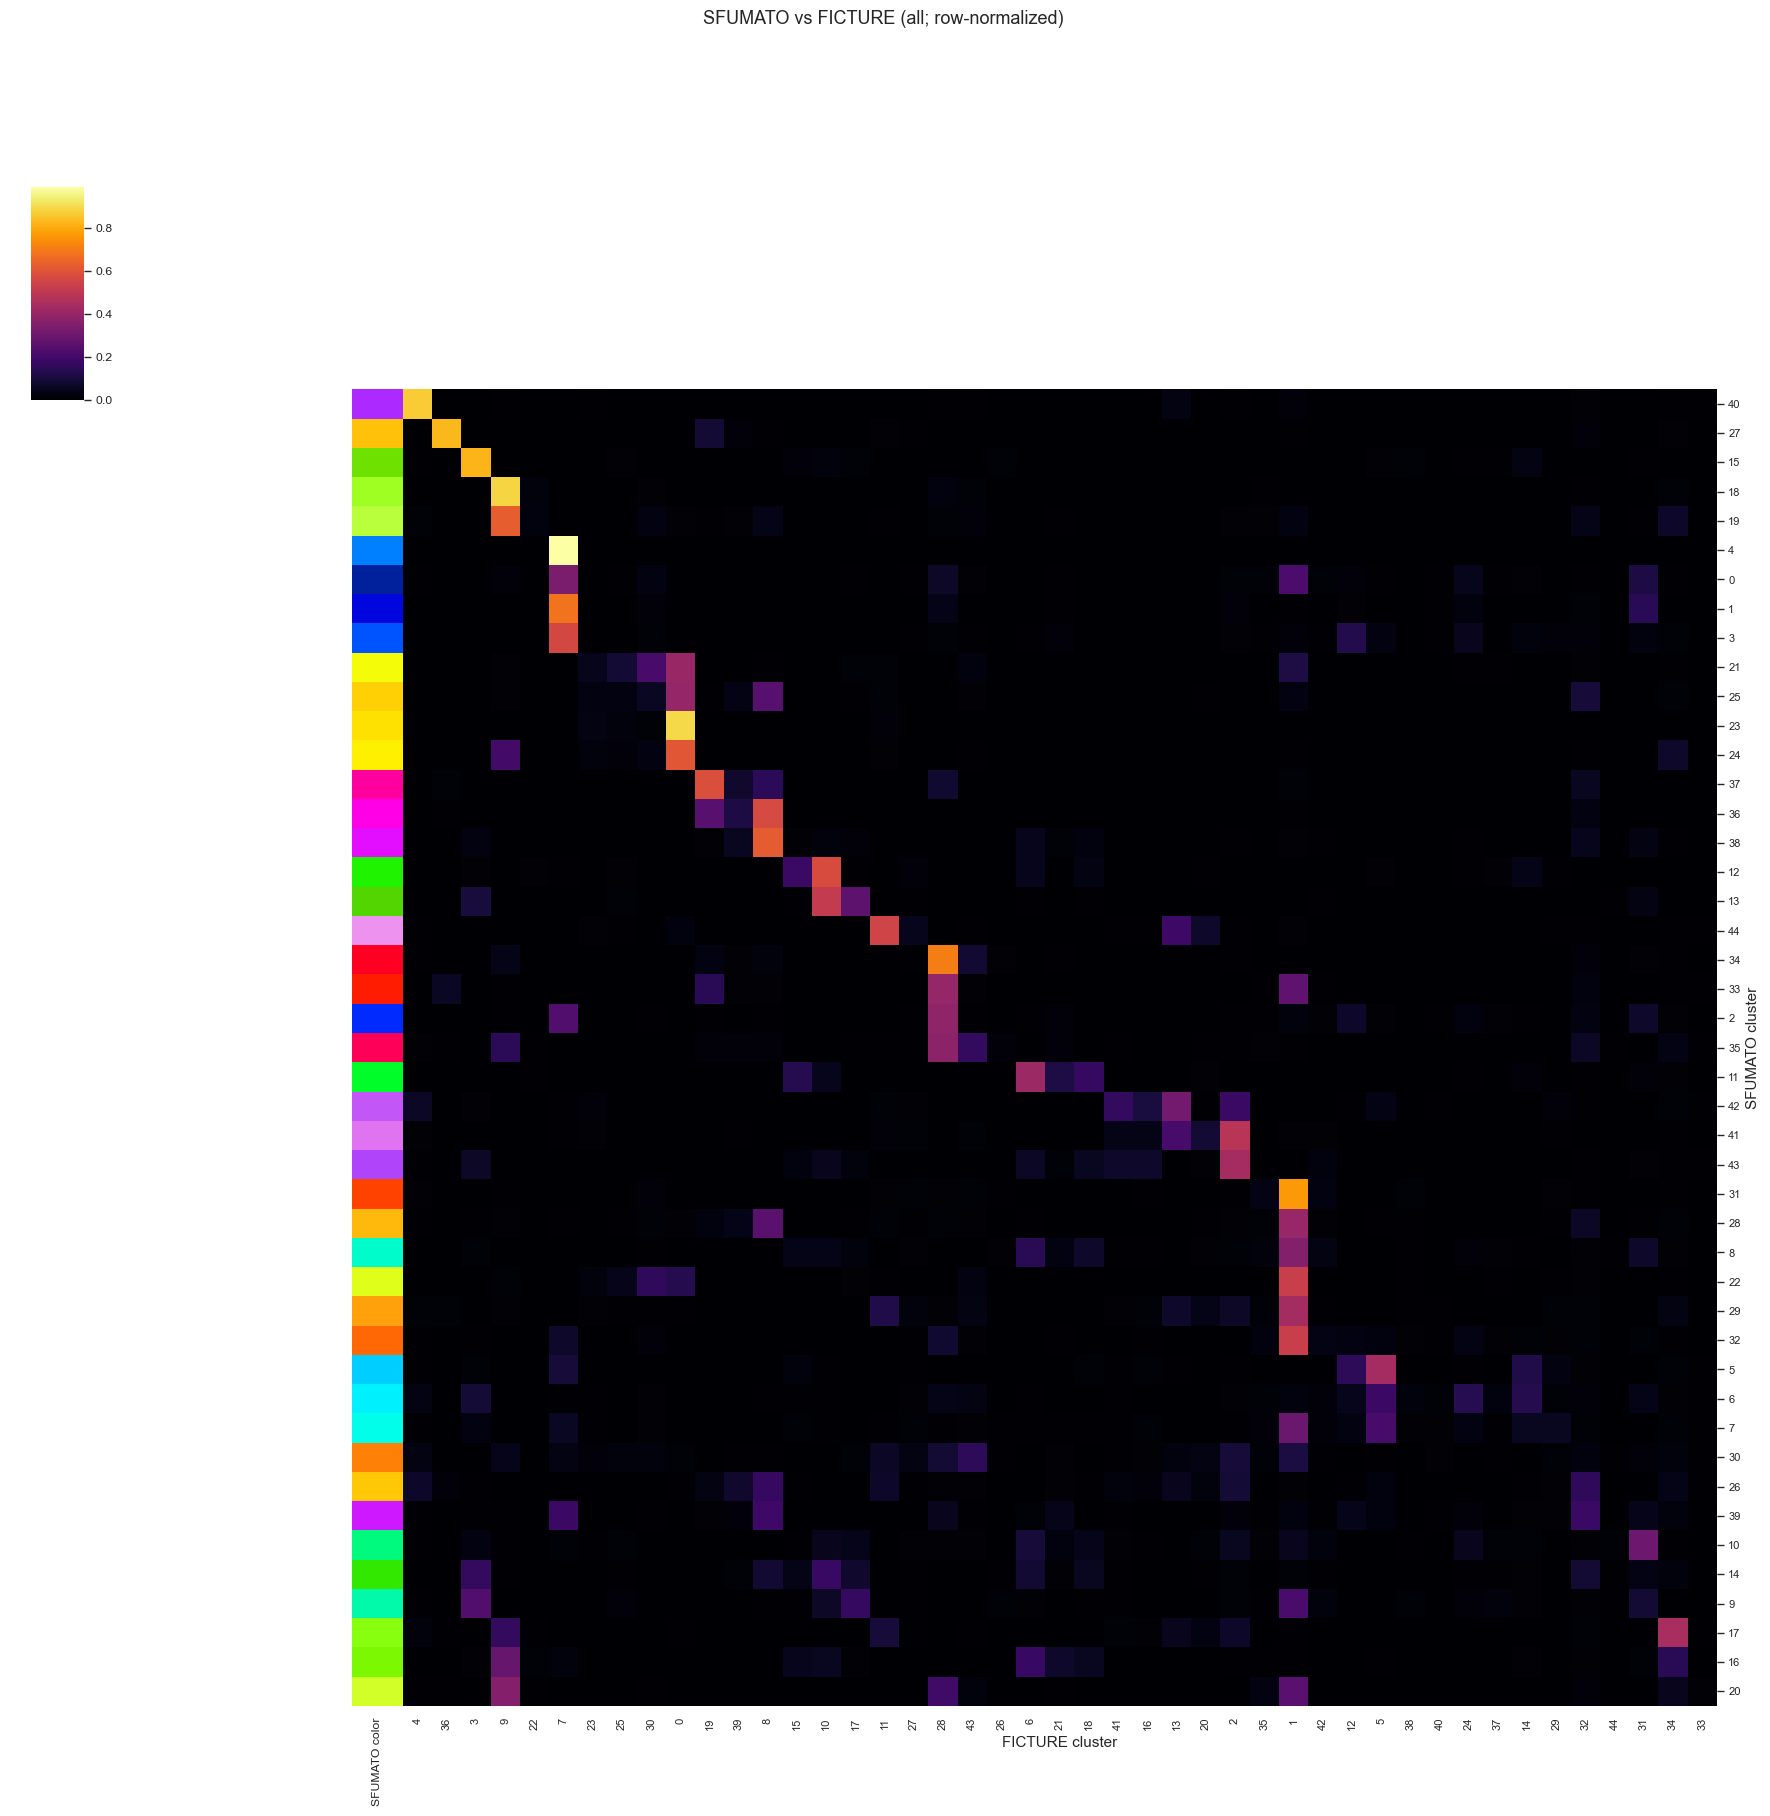

In [7]:
g_all = run_ficture_comparison(merged, label="all")


High-confidence threshold: p1 >= 0.8
High-confidence matched rows: 21,045,111 / 26,302,566
p1_ge_0_8: matrix shape = (45, 45); total overlap count = 21,045,111


ficture_cluster,0,1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,5,6,7,8,9
sfumato_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,118,19244,108,87,1066,71,860,55,192,348,112,99,808,66,359,92,99,4114,454,83,340,5127,220,104,2473,9268,501,114,249,935,29,584,224,84,319,335,139,924,757,135,445,199,30663,246,1271
1,4,598,12,41,856,36,139,12,134,88,45,103,1938,65,367,32,63,2664,16,17,314,4202,75,20,2079,19586,1393,70,399,222,63,104,136,77,216,564,161,234,298,102,66,127,89116,151,288
10,92,13366,15634,359,291,491,3674,1516,1880,14112,13954,281,18093,4642,7360,783,1225,17050,4285,563,3454,2653,415,8429,938,114179,2990,1152,1965,3359,232,4659,1533,357,1174,972,2190,6950,3050,4002,780,32275,4471,1022,2124
11,618,1212,57118,401,193,1801,32106,234356,2787,587,340401,250,4241,18847,248759,10025,1153,9602,3580,2043,2122,1470,595,2457,49,25104,9467,3392,13551,2845,434,1329,203,402,1774,294,1514,4683,609,1295,2709,870346,3298,454,1153
12,2195,191,440912,371,144,67,27748,125040,2150,1852,18297,45,911,2582,996,6097,2166,2985,4828,1368,12554,137,2681,3257,18,405,1540,317,859,27,157,8170,108,61,203,156,976,1655,96,1610,6982,26859,3385,141,44


Saved: sfumato_ficture_comparison\sfumato_vs_ficture_p1_ge_0_8.pdf


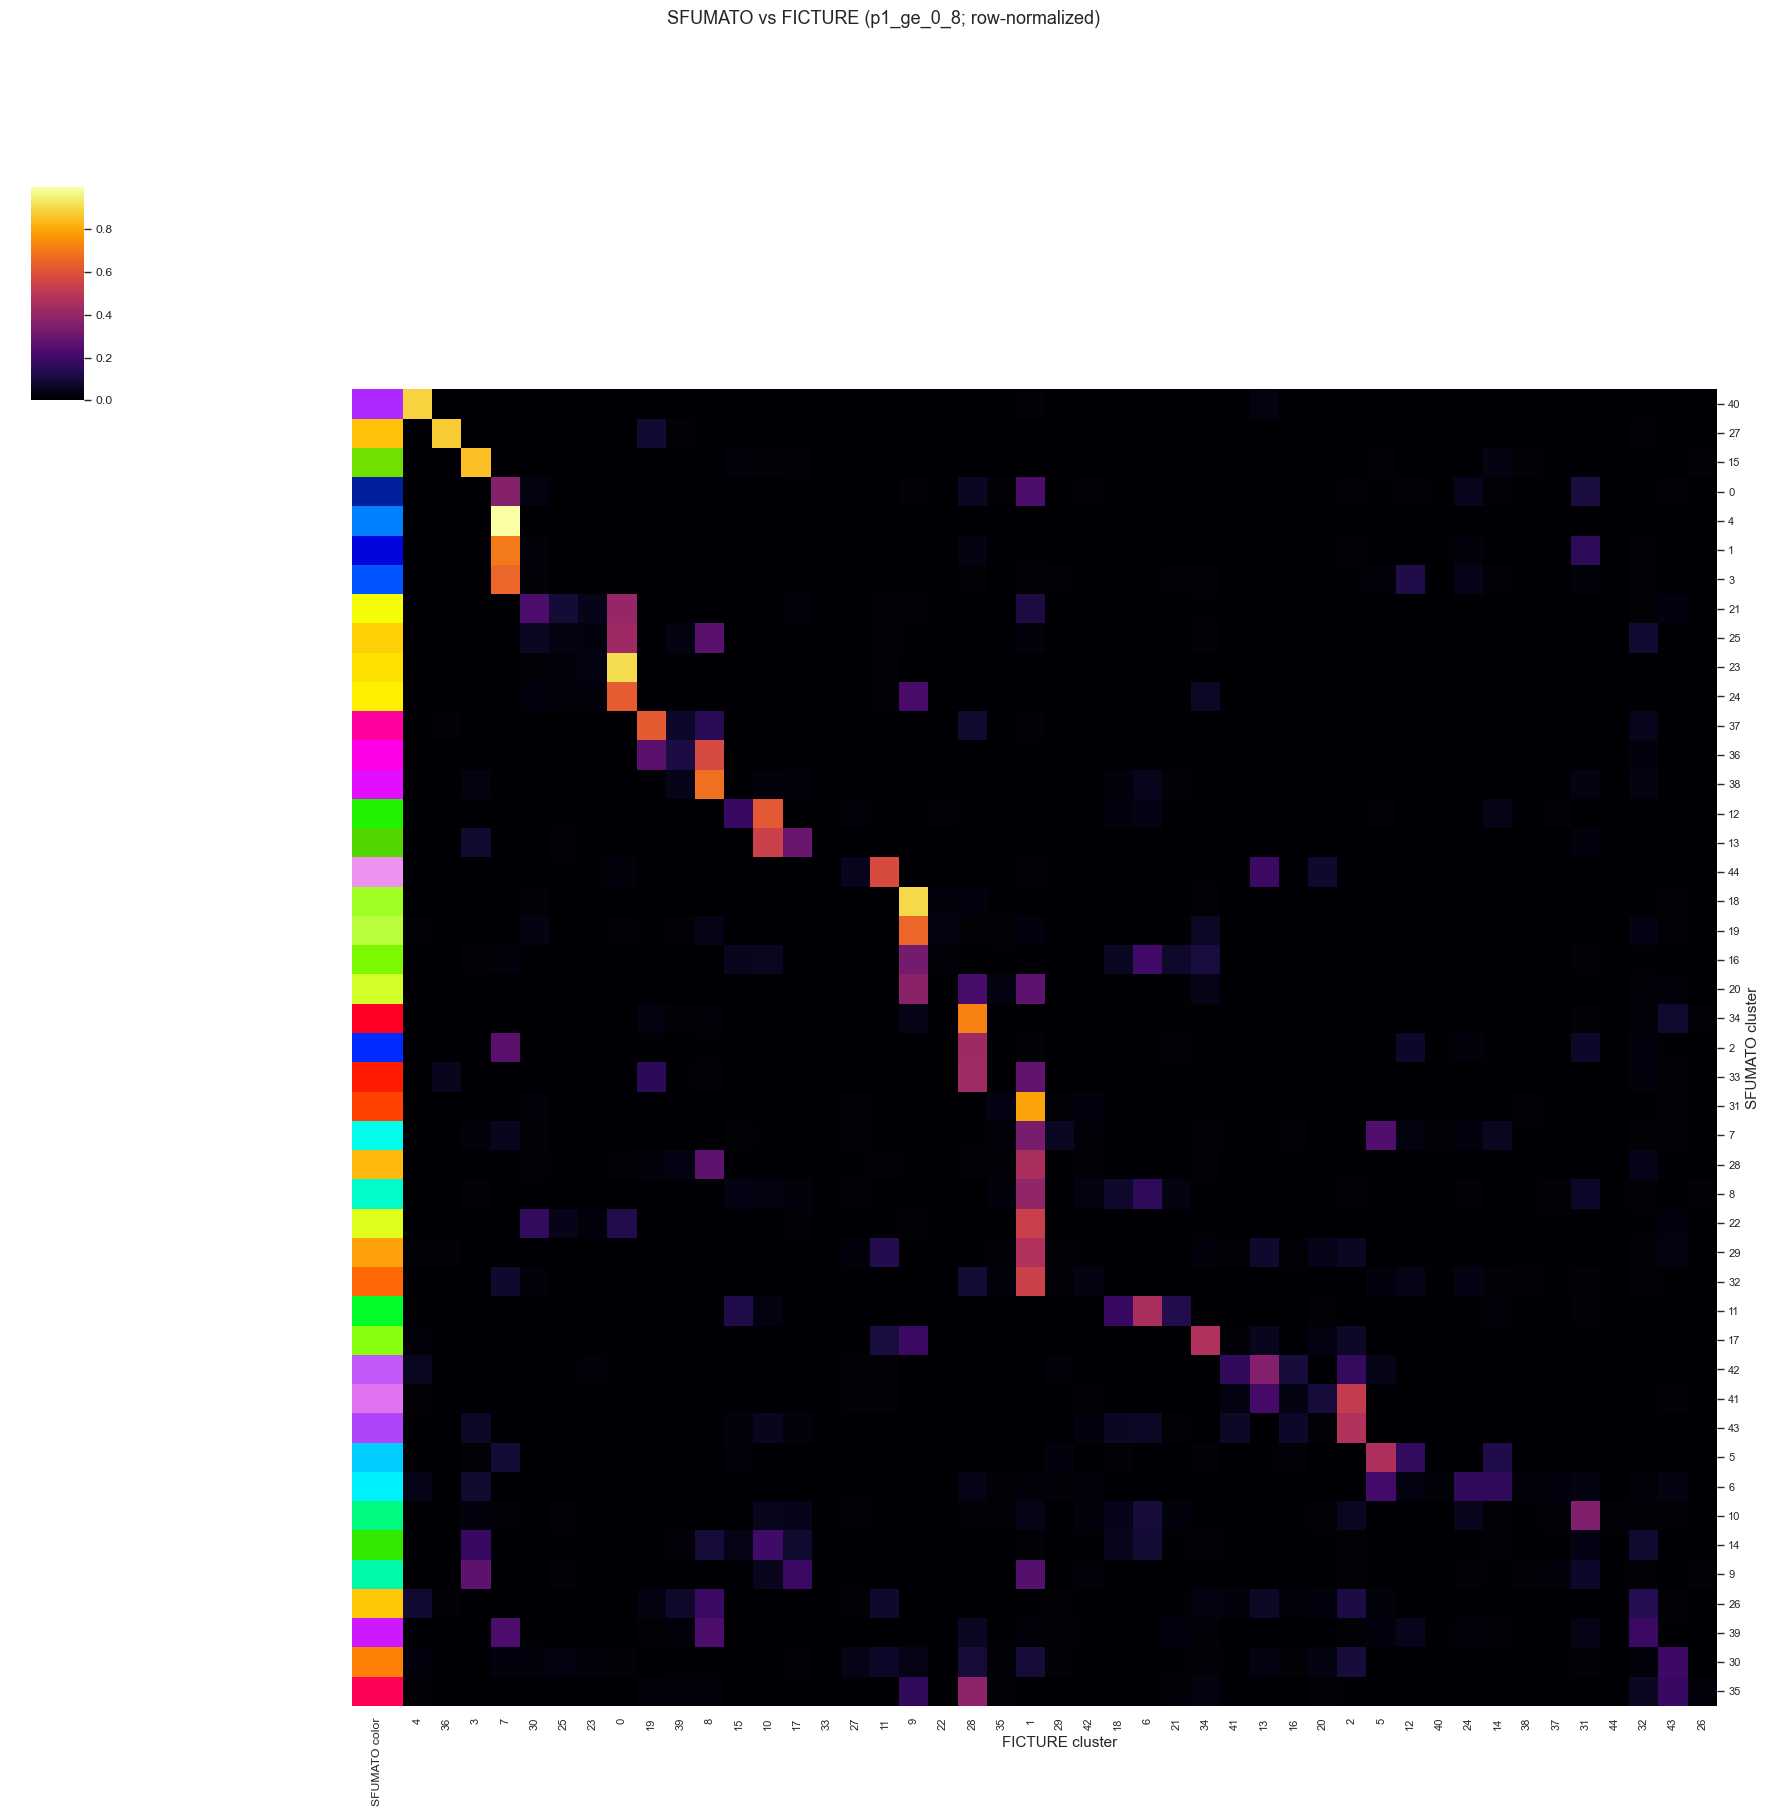

In [8]:
merged_high_conf = merged[merged["p1"] >= P1_THRESHOLD].copy()
print(f"High-confidence threshold: p1 >= {P1_THRESHOLD}")
print(f"High-confidence matched rows: {len(merged_high_conf):,} / {len(merged):,}")
g_high = run_ficture_comparison(merged_high_conf, label=f"p1_ge_{str(P1_THRESHOLD).replace('.', '_')}")
